### The goal of this file is to be able to take these 2D image slices and overlay them into a 3d model of an individual patient's heart

In [7]:
from pathlib import Path

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from skimage.measure import marching_cubes

In [8]:
DATA_DIR = Path("../data/training")
PATIENT = "patient001"

patient_dir = DATA_DIR / PATIENT

In [9]:
def read_patient_info(patient_dir):
    info = {}

    with open(patient_dir / "Info.cfg", "r") as f:
        for line in f:
            if ":" in line:
                key, value = line.strip().split(":", 1)
                info[key.strip()] = value.strip()

    return info

In [10]:
info = read_patient_info(patient_dir)

ed_frame = int(info["ED"])
es_frame = int(info["ES"])

print(info)

{'ED': '1', 'ES': '12', 'Group': 'DCM', 'Height': '184.0', 'NbFrame': '30', 'Weight': '95.0'}


In [11]:
ed_path = patient_dir / f"{PATIENT}_frame{ed_frame:02d}.nii.gz"
gt_path = patient_dir / f"{PATIENT}_frame{ed_frame:02d}_gt.nii.gz"

ed_img = nib.load(ed_path)
gt_img = nib.load(gt_path)

ed = ed_img.get_fdata()
gt = gt_img.get_fdata()

In [12]:
print("MRI shape:", ed.shape)
print("GT shape:", gt.shape)
print("Labels:", np.unique(gt))
print("Voxel spacing:", gt_img.header.get_zooms())

MRI shape: (216, 256, 10)
GT shape: (216, 256, 10)
Labels: [0. 1. 2. 3.]
Voxel spacing: (np.float32(1.5625), np.float32(1.5625), np.float32(10.0))


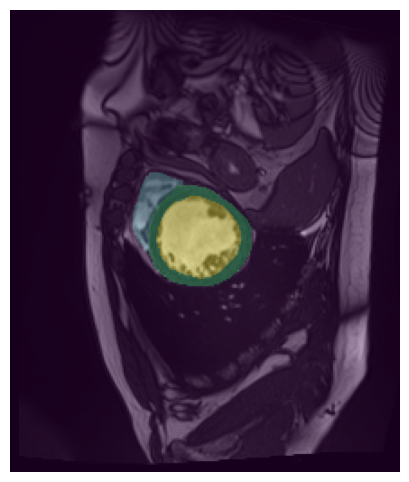

In [13]:
z = gt.shape[2] // 2

plt.figure(figsize=(6, 6))
plt.imshow(ed[:, :, z].T, cmap="gray", origin="lower")
plt.imshow(gt[:, :, z].T, cmap="viridis", alpha=0.35, origin="lower")
plt.axis("off")
plt.show()

In [14]:
lv_mask = gt == 3

In [15]:
print("LV voxels:", lv_mask.sum())

LV voxels: 12104


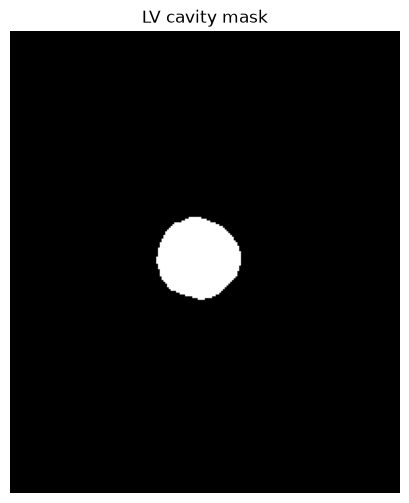

In [16]:
plt.figure(figsize=(6, 6))
plt.imshow(lv_mask[:, :, z].T, cmap="gray", origin="lower")
plt.title("LV cavity mask")
plt.axis("off")
plt.show()

In [17]:
spacing = gt_img.header.get_zooms()[:3]

print("Voxel spacing:", spacing)

Voxel spacing: (np.float32(1.5625), np.float32(1.5625), np.float32(10.0))


In [18]:
verts, faces, normals, values = marching_cubes(
    lv_mask.astype(np.uint8),
    level=0.5,
    spacing=spacing
)

In [19]:
print("Vertices:", verts.shape)
print("Faces:", faces.shape)

Vertices: (4842, 3)
Faces: (9586, 3)


### 3D Model for Patient 1

In [20]:
fig = go.Figure(
    data=[
        go.Mesh3d(
            x=verts[:, 0],
            y=verts[:, 1],
            z=verts[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            opacity=0.7
        )
    ]
)

fig.update_layout(
    title=f"{PATIENT} - LV cavity at end diastole",
    scene=dict(
        aspectmode="data"
    )
)

fig.show()

In [21]:
rv_mask = gt == 1
myo_mask = gt == 2

In [22]:
def mask_to_mesh(mask, spacing):
    verts, faces, normals, values = marching_cubes(
        mask.astype(np.uint8),
        level=0.5,
        spacing=spacing
    )

    return verts, faces

In [23]:
lv_verts, lv_faces = mask_to_mesh(lv_mask, spacing)
rv_verts, rv_faces = mask_to_mesh(rv_mask, spacing)
myo_verts, myo_faces = mask_to_mesh(myo_mask, spacing)

In [24]:
es_gt_path = patient_dir / f"{PATIENT}_frame{es_frame:02d}_gt.nii.gz"

es_gt_img = nib.load(es_gt_path)
es_gt = es_gt_img.get_fdata()

es_lv_mask = es_gt == 3

In [25]:
voxel_volume_mm3 = np.prod(spacing)

lv_volume_ed_ml = lv_mask.sum() * voxel_volume_mm3 / 1000
lv_volume_es_ml = es_lv_mask.sum() * voxel_volume_mm3 / 1000

print("LV ED volume:", lv_volume_ed_ml, "mL")
print("LV ES volume:", lv_volume_es_ml, "mL")

LV ED volume: 295.5078125 mL
LV ES volume: 225.6103515625 mL
